In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("libraries imported successfully")

libraries imported successfully


In [7]:
#loading dataset
df = pd.read_csv("../data/faircredit_sa_dataset_verified.csv")

df.head()

,monthly_gross_income,statutory_deductions,monthly_net_income,declared_living_expenses,minimum_expense_norm,living_expenses_used,existing_debt_repayments,maintenance_obligations,discretionary_income_before_new_credit,requested_credit_amount,loan_term_months,annual_interest_rate_assumption,proposed_installment,remaining_after_proposed_credit,number_existing_credit_accounts,missed_payments_12m,arrears_amount,defaults_history,employment_months,income_variability_pct,savings_amount,credit_utilisation_pct,affordability_pass,synthetic_risk_probability,faircredit_readiness_score,credit_risk
0,"43,088.02","3,944.10","39,143.92","21,497.05","4,338.60","21,497.05","4,189.38","2,694.83","10,762.66","98,541.60",12,0.22,"9,239.47","1,523.19",1,0,0.00,0,47,15.20,"7,064.12",43.40,1,0.48,52,0
1,"6,026.02",146.49,"5,879.53","3,130.88","1,152.76","3,130.88",414.44,390.20,"1,944.01","11,895.62",24,0.26,642.68,"1,301.33",0,1,0.00,0,46,10.50,857.87,32.50,1,0.42,58,0
2,"29,165.32","1,798.91","27,366.41","7,990.87","3,196.94","7,990.87","2,231.99",0.00,"17,143.55","86,332.74",6,0.30,"15,682.32","1,461.23",0,0,0.00,0,10,19.20,"14,955.68",28.60,1,0.56,44,1
3,"16,531.76","1,186.74","15,345.02","8,225.40","2,093.24","8,225.40","3,408.19",0.00,"3,711.43","6,625.32",12,0.18,606.96,"3,104.47",2,2,0.00,0,49,13.60,"46,388.53",74.80,1,0.35,65,1
4,"3,938.77",101.58,"3,837.19",558.07,"1,011.87","1,011.87",571.90,0.00,"2,253.42","11,584.09",24,0.23,609.54,"1,643.88",0,2,0.00,0,49,8.80,989.37,60.30,1,0.58,42,0


In [8]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 26


In [9]:
df.columns.tolist()


['monthly_gross_income',
 'statutory_deductions',
 'monthly_net_income',
 'declared_living_expenses',
 'minimum_expense_norm',
 'living_expenses_used',
 'existing_debt_repayments',
 'maintenance_obligations',
 'discretionary_income_before_new_credit',
 'requested_credit_amount',
 'loan_term_months',
 'annual_interest_rate_assumption',
 'proposed_installment',
 'remaining_after_proposed_credit',
 'number_existing_credit_accounts',
 'missed_payments_12m',
 'arrears_amount',
 'defaults_history',
 'employment_months',
 'income_variability_pct',
 'savings_amount',
 'credit_utilisation_pct',
 'affordability_pass',
 'synthetic_risk_probability',
 'faircredit_readiness_score',
 'credit_risk']

In [10]:
# Data types and basic structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   monthly_gross_income                    10000 non-null  float64
 1   statutory_deductions                    10000 non-null  float64
 2   monthly_net_income                      10000 non-null  float64
 3   declared_living_expenses                10000 non-null  float64
 4   minimum_expense_norm                    10000 non-null  float64
 5   living_expenses_used                    10000 non-null  float64
 6   existing_debt_repayments                10000 non-null  float64
 7   maintenance_obligations                 10000 non-null  float64
 8   discretionary_income_before_new_credit  10000 non-null  float64
 9   requested_credit_amount                 10000 non-null  float64
 10  loan_term_months                        10000 non-null  int64  
 11  a

In [11]:
#checking for missing values
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Missing %
monthly_gross_income,0,0.00
statutory_deductions,0,0.00
monthly_net_income,0,0.00
declared_living_expenses,0,0.00
minimum_expense_norm,0,0.00
living_expenses_used,0,0.00
existing_debt_repayments,0,0.00
maintenance_obligations,0,0.00
discretionary_income_before_new_credit,0,0.00
requested_credit_amount,0,0.00


In [12]:
#duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [13]:
#desrictive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_gross_income,"10,000.00","19,175.42","17,682.10","1,200.05","7,020.03","13,114.39","24,035.44","89,968.46"
statutory_deductions,"10,000.00","1,788.93","3,122.12",12.02,205.93,577.68,"1,684.20","20,684.73"
monthly_net_income,"10,000.00","17,386.49","14,759.35","1,159.30","6,805.48","12,508.94","22,362.63","72,042.04"
declared_living_expenses,"10,000.00","7,089.12","6,877.81",400.00,"2,425.07","4,836.82","9,251.51","46,490.73"
minimum_expense_norm,"10,000.00","2,287.34","1,437.15",827.00,"1,237.18","1,785.67","2,768.57","7,603.25"
living_expenses_used,"10,000.00","7,111.69","6,856.88",827.00,"2,425.07","4,836.82","9,251.51","46,490.73"
existing_debt_repayments,"10,000.00","3,030.58","4,172.67",0.00,658.90,"1,501.80","3,500.77","35,425.32"
maintenance_obligations,"10,000.00",228.86,534.75,0.00,0.00,0.00,0.00,"2,991.28"
discretionary_income_before_new_credit,"10,000.00","7,015.36","5,545.86","-6,479.38","3,020.71","5,525.67","9,672.15","42,107.59"
requested_credit_amount,"10,000.00","29,588.50","30,002.74","1,000.00","8,318.03","18,626.41","40,089.43","120,000.00"


In [14]:
# Affordability outcome distribution

df["affordability_pass"].value_counts()

affordability_pass
1    9704
0     296
Name: count, dtype: int64

In [15]:
# Affordability outcome percentages

df["affordability_pass"].value_counts(normalize=True) * 100

affordability_pass
1   97.04
0    2.96
Name: proportion, dtype: float64

In [16]:
# Credit risk distribution

df["credit_risk"].value_counts()

credit_risk
0    5757
1    4243
Name: count, dtype: int64

In [17]:
# Credit risk percentages

df["credit_risk"].value_counts(normalize=True) * 100

credit_risk
0   57.57
1   42.43
Name: proportion, dtype: float64

In [18]:
# Credit risk percentages

df["credit_risk"].value_counts(normalize=True) * 100

credit_risk
0   57.57
1   42.43
Name: proportion, dtype: float64

In [19]:
# FairCredit readiness score

df["faircredit_readiness_score"].describe()

count   10,000.00
mean        57.59
std         20.44
min          0.00
25%         45.00
50%         61.00
75%         74.00
max         95.00
Name: faircredit_readiness_score, dtype: float64

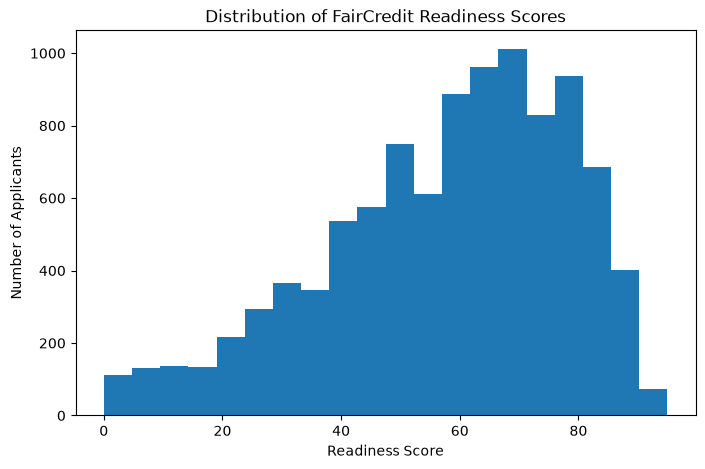

In [20]:
# Readiness score distribution

plt.figure(figsize=(8, 5))
plt.hist(df["faircredit_readiness_score"], bins=20)

plt.title("Distribution of FairCredit Readiness Scores")
plt.xlabel("Readiness Score")
plt.ylabel("Number of Applicants")

plt.show()

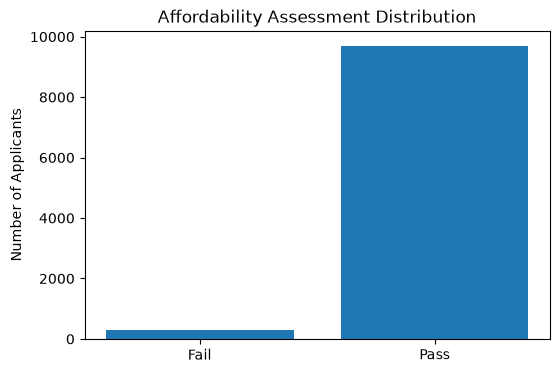

In [21]:
# Affordability result distribution

counts = df["affordability_pass"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Fail", "Pass"], counts.values)

plt.title("Affordability Assessment Distribution")
plt.ylabel("Number of Applicants")

plt.show()

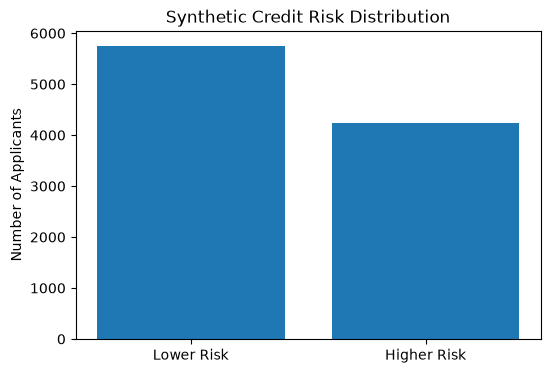

In [22]:
# Credit risk distribution

counts = df["credit_risk"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Lower Risk", "Higher Risk"], counts.values)

plt.title("Synthetic Credit Risk Distribution")
plt.ylabel("Number of Applicants")

plt.show()

In [23]:
# Correlations with credit risk

correlations = (
    df.corr(numeric_only=True)["credit_risk"]
    .sort_values(ascending=False)
)

correlations

credit_risk                               1.00
synthetic_risk_probability                0.43
credit_utilisation_pct                    0.30
missed_payments_12m                       0.23
existing_debt_repayments                  0.14
defaults_history                          0.13
arrears_amount                            0.12
proposed_installment                      0.11
number_existing_credit_accounts           0.10
requested_credit_amount                   0.08
living_expenses_used                      0.07
declared_living_expenses                  0.07
statutory_deductions                      0.06
monthly_gross_income                      0.06
minimum_expense_norm                      0.06
monthly_net_income                        0.05
income_variability_pct                    0.04
maintenance_obligations                   0.02
annual_interest_rate_assumption          -0.00
savings_amount                           -0.01
employment_months                        -0.03
loan_term_mon